# REQUIREMENTS

In [ ]:
import matplotlib.cm as cm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler



In [ ]:
# https://drive.google.com/file/d/1bptVfwvA0PCmT3dQj61dXkJ4CQsUrGgj/view?usp=sharing
final_dataset = pd.read_csv("https://drive.google.com/uc?export=download&id=1bptVfwvA0PCmT3dQj61dXkJ4CQsUrGgj")

# Converting 'time' column to datetime objects and set as index
final_dataset['time'] = pd.to_datetime(final_dataset['time'])
final_dataset.set_index('time', inplace=True)

# Loading the data
data = final_dataset.copy()



final_dataset.tail()

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,...,clouds_all_Barcelona,temp_Valencia,pressure_Valencia,humidity_Valencia,wind_speed_Valencia,wind_deg_Valencia,rain_1h_Valencia,rain_3h_Valencia,snow_3h_Valencia,clouds_all_Valencia
time,,,,,,,,,,,,,,,,,,,,,
2018-12-31 18:00:00+00:00,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0,...,0.0,285.64,1028.0,62.0,2.0,140.0,0.0,0.0,0.0,0.0
2018-12-31 19:00:00+00:00,296.0,0.0,7241.0,2566.0,174.0,1.0,1172.0,3931.0,6074.0,62.0,...,0.0,283.14,1029.0,71.0,1.0,242.0,0.0,0.0,0.0,0.0
2018-12-31 20:00:00+00:00,292.0,0.0,7025.0,2422.0,168.0,50.0,1148.0,2831.0,6076.0,61.0,...,0.0,281.66,1029.0,81.0,3.0,300.0,0.0,0.0,0.0,0.0
2018-12-31 21:00:00+00:00,293.0,0.0,6562.0,2293.0,163.0,108.0,1128.0,2068.0,6075.0,61.0,...,0.0,280.14,1029.0,81.0,2.0,310.0,0.0,0.0,0.0,0.0
2018-12-31 22:00:00+00:00,290.0,0.0,6926.0,2166.0,163.0,108.0,1069.0,1686.0,6075.0,61.0,...,0.0,279.14,1029.0,75.0,2.0,300.0,0.0,0.0,0.0,0.0




To decide if the best number of clusters is eaither 5 or 6 we use the Silhouette score




---



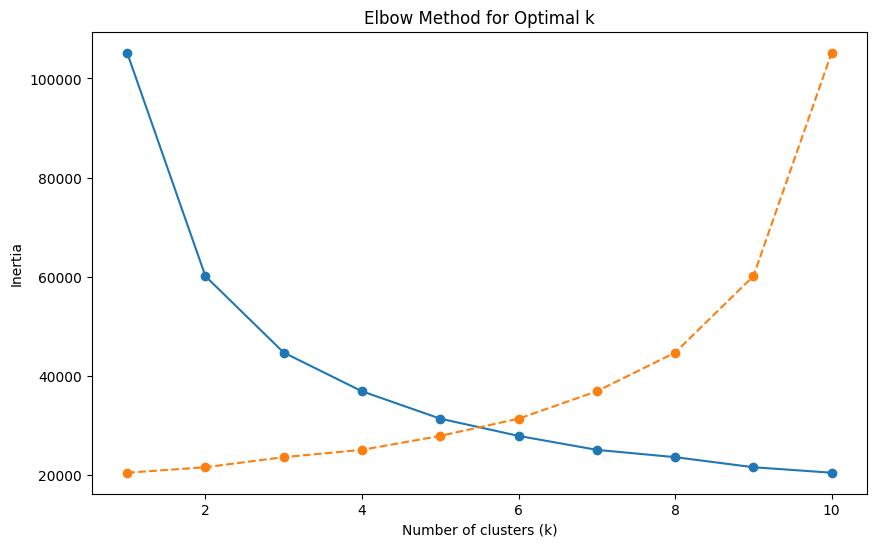

In [ ]:
# Select relevant features
features = ['generation fossil gas', 'total load actual', 'price actual']

# Normalizing the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(data[features])

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_normalized)
    inertias.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o')
plt.plot(k_range, inertias[::-1], marker='o', linestyle='--')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


In [ ]:

# N11ata = scaler.fit_transform(data[features])

# Applying K-means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
data['cluster'] = kmeans.fit_predict(X_normalized)

# Analyzing the results
print(data.groupby('cluster')[features].mean())


         generation fossil gas  total load actual  price actual
cluster                                                        
0                  3913.762315       24257.093352     37.373390
1                  5857.888504       31599.105368     71.253238
2                  5040.926532       31468.191156     51.641661
3                  4716.249493       24575.547585     58.852497
4                 10096.917667       33925.771320     69.209497


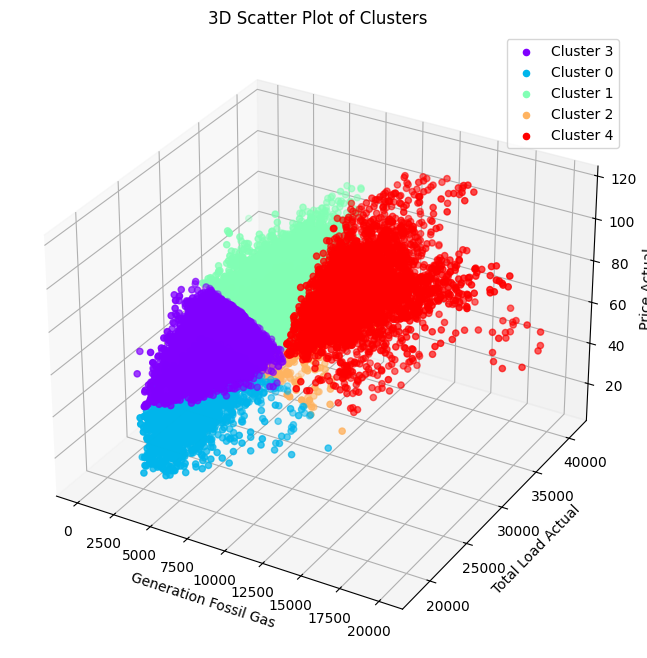

In [ ]:

# Applying K-means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
data['cluster'] = kmeans.fit_predict(X_normalized)

# Creating a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting each cluster
colors = cm.rainbow(np.linspace(0, 1, len(data['cluster'].unique())))
for cluster, color in zip(data['cluster'].unique(), colors):
    cluster_data = data[data['cluster'] == cluster]
    ax.scatter(cluster_data['generation fossil gas'],
               cluster_data['total load actual'],
               cluster_data['price actual'],
               c=[color], label=f'Cluster {cluster}')

ax.set_xlabel('Generation Fossil Gas')
ax.set_ylabel('Total Load Actual')
ax.set_zlabel('Price Actual')
ax.set_title('3D Scatter Plot of Clusters')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# Validating the cluster numbers
silhouette_avg = silhouette_score(normalized_data, kmeans.labels_)
print(f"The average silhouette score is: {silhouette_avg:.4f}")
# 6 cluster => 0.2812
# 5 cluster => 0.2888
# 4 clusters => 0.2863

The average silhouette score is: 0.2888
